In [1]:
import requests
import numpy as np
import rasterio
from rasterio.merge import merge
from rasterio.mask import mask
from rasterio.transform import from_origin
import pyproj
from shapely.geometry import shape, mapping
from shapely.ops import transform as shp_transform
import os, json

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36",
    "Referer": "https://www.ign.es/",
}
from pathlib import Path

RAW_DIR     = Path("../../data/raw/03_pendiente_dem")
DELIM_DIR   = Path("../../data/raw/delimitations")
RAW_DIR.mkdir(parents=True, exist_ok=True)

TILE_DIR    = RAW_DIR / "tiles_huesca"
TILE_SIZE   = 10000
MOSAIC_TIF  = os.path.join(TILE_DIR, "_mosaic_5m.tif")
SLOPE_5M    = os.path.join(TILE_DIR, "_slope_5m.tif")
OUTPUT_TIF  = RAW_DIR / "pendiente_huesca_provincia.tif"
CHUNK       = 2048          # filas procesadas a la vez; bájalo a 1024 si el PC se queda sin RAM
OVERLAP     = 2             # píxeles de solape para el gradiente en bordes
os.makedirs(TILE_DIR, exist_ok=True)

GEOJSON_HUESCA = DELIM_DIR / "Huesca_Delimitacion.geojson"

# ── 1. Cargar GeoJSON y reproyectar a EPSG:25830 ──────────────────────────
with open(GEOJSON_HUESCA) as f:
    geojson = json.load(f)

if geojson["type"] == "FeatureCollection":
    geom = shape(geojson["features"][0]["geometry"])
elif geojson["type"] == "Feature":
    geom = shape(geojson["geometry"])
else:
    geom = shape(geojson)

project  = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:25830", always_xy=True).transform
geom_utm = shp_transform(project, geom)

X_MIN, Y_MIN, X_MAX, Y_MAX = [int(v) for v in geom_utm.bounds]
print(f"Bbox UTM25830: ({X_MIN}, {Y_MIN}) → ({X_MAX}, {Y_MAX})")

# ── 2. Descargar tiles MDT a 5m (paralelo, con reanudación) ──────────────
from concurrent.futures import ThreadPoolExecutor, as_completed
import threading

MAX_WORKERS = 8   # nº de descargas simultáneas — sube/baja según cómo responda el servidor

xs    = list(range(X_MIN, X_MAX, TILE_SIZE))
ys    = list(range(Y_MIN, Y_MAX, TILE_SIZE))
tile_coords = [(x0, y0) for x0 in xs for y0 in ys]
total = len(tile_coords)

print_lock = threading.Lock()
progress = {"done": 0}

def descargar_tile(coords):
    x0, y0 = coords
    x1, y1 = x0 + TILE_SIZE, y0 + TILE_SIZE
    tile_path = os.path.join(TILE_DIR, f"tile_{x0}_{y0}.tif")

    if os.path.exists(tile_path):
        with print_lock:
            progress["done"] += 1
            print(f"[{progress['done']}/{total}] CACHED ({x0},{y0})")
        return tile_path

    qs = (
        "service=WCS&version=2.0.1&request=GetCoverage"
        "&coverageId=Elevacion25830_5"
        "&format=image/tiff"
        f"&subset=x({x0},{x1})"
        f"&subset=y({y0},{y1})"
        "&subsettingCrs=http://www.opengis.net/def/crs/EPSG/0/25830"
        "&outputCrs=http://www.opengis.net/def/crs/EPSG/0/25830"
    )
    try:
        r = requests.get(
            f"https://servicios.idee.es/wcs-inspire/mdt?{qs}",
            headers=HEADERS, timeout=120,
        )
        with print_lock:
            progress["done"] += 1
        if "tiff" not in r.headers.get("Content-Type", ""):
            with print_lock:
                print(f"[{progress['done']}/{total}] SKIP ({x0},{y0}): {r.text[:100]}")
            return None
        with open(tile_path, "wb") as fout:
            fout.write(r.content)
        with print_lock:
            print(f"[{progress['done']}/{total}] OK ({x0},{y0})")
        return tile_path
    except Exception as e:
        with print_lock:
            progress["done"] += 1
            print(f"[{progress['done']}/{total}] ERROR ({x0},{y0}): {e}")
        return None

tile_files = []
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = [executor.submit(descargar_tile, c) for c in tile_coords]
    for future in as_completed(futures):
        result = future.result()
        if result:
            tile_files.append(result)

print(f"\nDescarga completa: {len(tile_files)}/{total} tiles")

# ── 3. Merge de tiles → GeoTIFF comprimido en disco ──────────────────────
if not os.path.exists(MOSAIC_TIF):
    print(f"\nMerging {len(tile_files)} tiles → {MOSAIC_TIF} ...")
    datasets = [rasterio.open(f) for f in tile_files]
    mosaic, transform = merge(datasets)
    profile = datasets[0].profile.copy()
    profile.update(
        driver="GTiff",
        width=mosaic.shape[2],
        height=mosaic.shape[1],
        transform=transform,
        compress="deflate",
        tiled=True,
        blockxsize=512,
        blockysize=512,
        bigtiff="YES",
    )
    for ds in datasets:
        ds.close()
    with rasterio.open(MOSAIC_TIF, "w", **profile) as dst:
        dst.write(mosaic)
    del mosaic   # liberar RAM inmediatamente
    print("Mosaic guardado.")
else:
    print(f"Mosaic ya existe: {MOSAIC_TIF}")

# ── 4. Calcular pendiente por CHUNKS y escribir a disco ───────────────────
print(f"\nCalculando pendiente por chunks de {CHUNK} filas (overlap={OVERLAP})...")

with rasterio.open(MOSAIC_TIF) as src:
    H, W   = src.height, src.width
    nodata = src.nodata if src.nodata is not None else -9999
    prof5  = src.profile.copy()

prof5.update(
    dtype="float32",
    nodata=-9999,
    compress="deflate",
    tiled=True,
    blockxsize=512,
    blockysize=512,
    bigtiff="YES",
)

with rasterio.open(SLOPE_5M, "w", **prof5) as dst:
    with rasterio.open(MOSAIC_TIF) as src:
        row = 0
        while row < H:
            # Ventana con solape
            r_start = max(row - OVERLAP, 0)
            r_end   = min(row + CHUNK + OVERLAP, H)

            win     = rasterio.windows.Window(0, r_start, W, r_end - r_start)
            dem     = src.read(1, window=win).astype("float32")
            dem[dem == nodata] = np.nan

            dy, dx  = np.gradient(dem, 5.0)
            slope_chunk = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))
            slope_chunk = np.nan_to_num(slope_chunk, nan=-9999).astype("float32")

            # Recortar el solape para escribir solo las filas "buenas"
            top_cut    = row - r_start          # cuántas filas solapadas hay arriba
            bottom_cut = r_end - (row + CHUNK)  # cuántas filas solapadas hay abajo
            actual_end = row + CHUNK if row + CHUNK < H else H
            n_rows     = actual_end - row

            write_data = slope_chunk[top_cut : top_cut + n_rows, :]
            win_write  = rasterio.windows.Window(0, row, W, n_rows)
            dst.write(write_data, 1, window=win_write)

            pct = min((row + CHUNK) / H * 100, 100)
            print(f"  Filas {row}–{actual_end-1} / {H}  ({pct:.0f}%)")
            row += CHUNK

print(f"Pendiente 5m guardada: {SLOPE_5M}")

# ── 5. Resample 5m → 25m por bloques ─────────────────────────────────────
print("\nResampleando 5m → 25m (average, bloques)...")
FACTOR = 5

with rasterio.open(SLOPE_5M) as src:
    H5, W5  = src.height, src.width
    tf5     = src.transform
    H25     = H5 // FACTOR
    W25     = W5 // FACTOR

    new_tf  = from_origin(tf5.c, tf5.f, tf5.a * FACTOR, abs(tf5.e) * FACTOR)
    prof25  = src.profile.copy()
    prof25.update(
        width=W25, height=H25, transform=new_tf,
        dtype="float32", nodata=-9999,
        compress="deflate", tiled=True,
        blockxsize=512, blockysize=512,
        bigtiff="YES",
    )

    SLOPE_25_TMP = os.path.join(TILE_DIR, "_slope_25m_tmp.tif")
    with rasterio.open(SLOPE_25_TMP, "w", **prof25) as dst:
        row5 = 0
        while row5 < H25 * FACTOR:
            n5       = min(CHUNK * FACTOR, H25 * FACTOR - row5)
            n25      = n5 // FACTOR
            win5     = rasterio.windows.Window(0, row5, W5, n5)
            data5    = src.read(1, window=win5).astype("float32")

            # Recortar a múltiplo exacto de FACTOR
            data5    = data5[:n25 * FACTOR, :W25 * FACTOR]
            data25   = (
                data5
                .reshape(n25, FACTOR, W25, FACTOR)
                .mean(axis=(1, 3))
                .astype("float32")
            )
            # Propagar nodata
            nd_mask  = (
                (data5 == -9999)
                .reshape(n25, FACTOR, W25, FACTOR)
                .any(axis=(1, 3))
            )
            data25[nd_mask] = -9999

            row25    = row5 // FACTOR
            win25    = rasterio.windows.Window(0, row25, W25, n25)
            dst.write(data25, 1, window=win25)

            pct = min((row5 + n5) / (H25 * FACTOR) * 100, 100)
            print(f"  Filas 5m {row5}–{row5+n5-1}  ({pct:.0f}%)")
            row5 += n5

print(f"Resample completado: {SLOPE_25_TMP}")

# ── 6. Clip al límite provincial ──────────────────────────────────────────
print("\nClipping al límite provincial...")
with rasterio.open(SLOPE_25_TMP) as src:
    clipped, clipped_tf = mask(src, [mapping(geom_utm)], crop=True, nodata=-9999)
    clipped_profile = src.profile.copy()
    clipped_profile.update(
        width=clipped.shape[2], height=clipped.shape[1],
        transform=clipped_tf, compress="deflate",
    )

os.unlink(SLOPE_25_TMP)

# ── 7. Guardar resultado final ────────────────────────────────────────────
with rasterio.open(OUTPUT_TIF, "w", **clipped_profile) as dst:
    dst.write(clipped)

valid = clipped[0][clipped[0] != -9999]
print(f"\n✓ Guardado: {OUTPUT_TIF}")
print(f"  Resolución  : 25m × 25m")
print(f"  Dimensiones : {clipped_profile['width']} × {clipped_profile['height']} px")
print(f"  Tamaño mem. : {clipped.nbytes / 1e6:.1f} MB")
print(f"  Min={valid.min():.1f}°  Max={valid.max():.1f}°  Media={valid.mean():.1f}°")
print(f"  Píxeles válidos: {len(valid):,}  |  Nodata: {(clipped[0]==-9999).sum():,}")

Bbox UTM25830: (669547, 4581688) → (810631, 4754656)
[1/270] CACHED (669547,4581688)
[2/270] CACHED (669547,4591688)
[3/270] CACHED (669547,4601688)
[4/270] CACHED (669547,4611688)
[5/270] CACHED (669547,4621688)
[6/270] CACHED (669547,4631688)
[7/270] CACHED (669547,4651688)
[8/270] CACHED (669547,4661688)
[9/270] CACHED (669547,4641688)
[10/270] CACHED (669547,4671688)
[11/270] CACHED (669547,4681688)
[12/270] CACHED (669547,4691688)
[13/270] CACHED (669547,4701688)
[14/270] CACHED (669547,4711688)
[15/270] CACHED (669547,4721688)
[16/270] CACHED (669547,4731688)
[17/270] CACHED (669547,4741688)
[18/270] CACHED (669547,4751688)
[19/270] CACHED (679547,4581688)
[20/270] CACHED (679547,4591688)
[21/270] CACHED (679547,4621688)
[22/270] CACHED (679547,4631688)
[23/270] CACHED (679547,4611688)
[24/270] CACHED (679547,4641688)
[25/270] CACHED (679547,4601688)
[26/270] CACHED (679547,4651688)
[27/270] CACHED (679547,4671688)
[28/270] CACHED (679547,4661688)
[29/270] CACHED (679547,4681688)

  Filas 0–2047 / 36000  (6%)


  Filas 2048–4095 / 36000  (11%)


  Filas 4096–6143 / 36000  (17%)


  Filas 6144–8191 / 36000  (23%)


...

  Filas 5m 0–10239  (28%)


  Filas 5m 10240–20479  (57%)


  Filas 5m 20480–30719  (85%)


  Filas 5m 30720–35999  (100%)
Resample completado: ../../data/raw/03_pendiente_dem/tiles_huesca/_slope_25m_tmp.tif

Clipping al límite provincial...



✓ Guardado: ../../data/raw/03_pendiente_dem/pendiente_huesca_provincia.tif
  Resolución  : 25m × 25m
  Dimensiones : 5644 × 6919 px
  Tamaño mem. : 156.2 MB
  Min=0.0°  Max=83.9°  Media=15.1°
  Píxeles válidos: 25,082,591  |  Nodata: 13,968,245


In [2]:
import numpy as np
import rasterio
import pandas as pd
import pydeck as pdk
from pyproj import Transformer
from pathlib import Path

RAW_DIR = Path("../../data/raw/03_pendiente_dem")
MAP_DIR = Path("../../data/map/03_pendiente_dem")
RAW_DIR.mkdir(parents=True, exist_ok=True)
MAP_DIR.mkdir(parents=True, exist_ok=True)

# --- Leer TIF ---
with rasterio.open(RAW_DIR / "pendiente_huesca_provincia.tif") as src:
    slope = src.read(1).astype("float32")
    nodata = src.nodata or -9999
    slope[slope == nodata] = np.nan
    transform = src.transform

# --- Submuestrear ---
step = 25

slope_sub = slope[::step, ::step]
rows, cols = slope_sub.shape

xs = np.array([transform.c + (j * step + step/2) * transform.a for j in range(cols)])
ys = np.array([transform.f + (i * step + step/2) * transform.e for i in range(rows)])
X, Y = np.meshgrid(xs, ys)

mask = ~np.isnan(slope_sub)
x_flat = X[mask]
y_flat = Y[mask]
s_flat = slope_sub[mask]

# --- UTM25830 → WGS84 ---
tr = Transformer.from_crs("EPSG:25830", "EPSG:4326", always_xy=True)
lon, lat = tr.transform(x_flat, y_flat)

# --- Color por clase de pendiente (RGBA) ---
def slope_color(s):
    if s < 5:   return [34,  139, 34,  200]   # verde oscuro — plano
    if s < 15:  return [144, 238, 144, 200]   # verde claro  — suave
    if s < 30:  return [255, 255, 100, 220]   # amarillo     — moderado
    if s < 45:  return [255, 140, 0,   230]   # naranja      — fuerte
    return              [180, 0,   0,   255]   # rojo         — extremo

colors = np.array([slope_color(s) for s in s_flat], dtype=np.uint8)

df = pd.DataFrame({
    "lon":       lon,
    "lat":       lat,
    "pendiente": s_flat,
    "elevacion": s_flat * 160,   # escala visual Z (ajusta el *80 a tu gusto)
    "r": colors[:, 0],
    "g": colors[:, 1],
    "b": colors[:, 2],
    "a": colors[:, 3],
})

print(f"Puntos: {len(df):,}")

# --- ColumnLayer: columnas 3D de altura proporcional a la pendiente ---
layer = pdk.Layer(
    "ColumnLayer",
    data=df,
    get_position=["lon", "lat"],
    get_elevation="elevacion",
    get_fill_color=["r", "g", "b", "a"],
    radius=200,          # radio de cada columna en metros — baja si step es pequeño
    elevation_scale=1,
    pickable=True,
    auto_highlight=True,
)

view = pdk.ViewState(
    longitude=-0.08,
    latitude=42.10,      # centrado en Huesca provincia
    zoom=8,
    min_zoom=7,
    max_zoom=12,
    pitch=50,
    bearing=-20,
)

tooltip = {
    "html": "<b>Pendiente:</b> {pendiente:.1f}°",
    "style": {"backgroundColor": "#111", "color": "white", "fontSize": "12px"},
}

r = pdk.Deck(
    layers=[layer],
    initial_view_state=view,
    tooltip=tooltip,
    map_style="https://basemaps.cartocdn.com/gl/dark-matter-gl-style/style.json",
)

output_html = MAP_DIR / "mapa_pendiente_3d_huesca.html"
r.to_html(str(output_html))
print(f"Abre: {output_html}")

Puntos: 40,125


Abre: ../../data/map/03_pendiente_dem/mapa_pendiente_3d_huesca.html


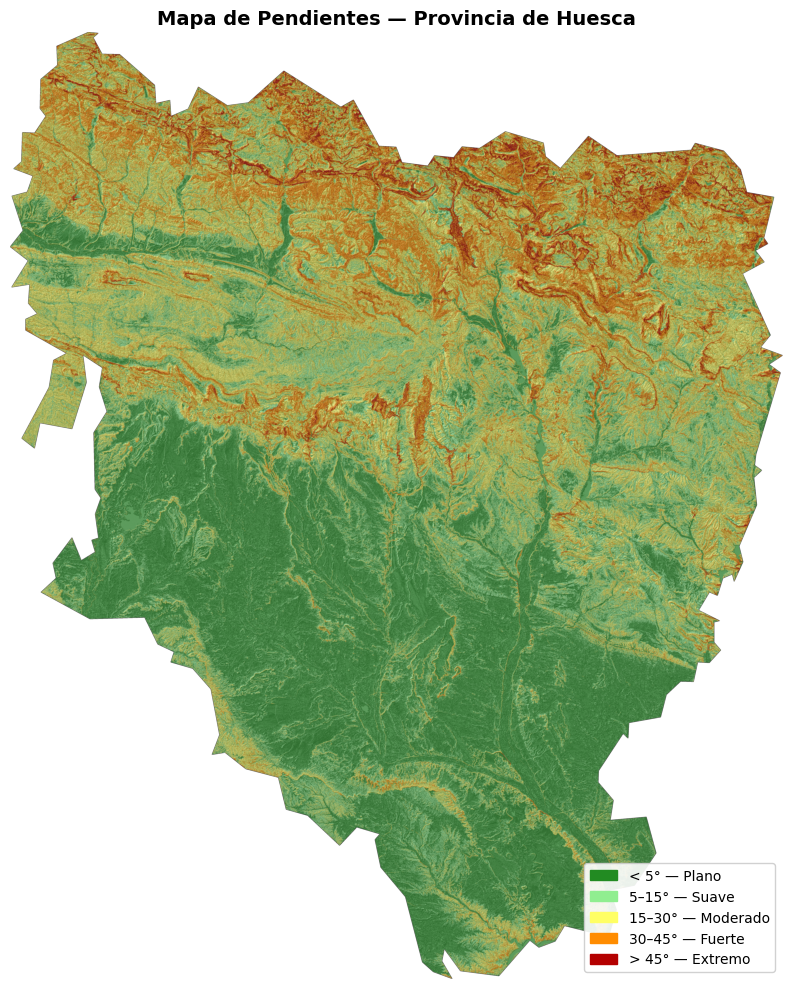

Guardado: ../../data/map/03_pendiente_dem/mapa_pendiente_huesca.png


In [3]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LightSource
from matplotlib.patches import Patch
from pathlib import Path

RAW_DIR = Path("../../data/raw/03_pendiente_dem")
MAP_DIR = Path("../../data/map/03_pendiente_dem")
RAW_DIR.mkdir(parents=True, exist_ok=True)
MAP_DIR.mkdir(parents=True, exist_ok=True)

# --- Leer TIF ---
with rasterio.open(RAW_DIR / "pendiente_huesca_provincia.tif") as src:    
    slope = src.read(1).astype("float32")
    nodata = src.nodata or -9999
    slope[slope == nodata] = np.nan

# --- Hillshade ---
ls = LightSource(azdeg=315, altdeg=45)
hillshade = ls.hillshade(slope, vert_exag=2)

# --- Colormap por clases ---
cmap = mcolors.ListedColormap([
    "#228B22",   # < 5°   plano
    "#90EE90",   # 5-15°  suave
    "#FFFF64",   # 15-30° moderado
    "#FF8C00",   # 30-45° fuerte
    "#B40000",   # > 45°  extremo
])
bounds = [0, 5, 15, 30, 45, 90]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 10))

ax.imshow(hillshade, cmap="gray", interpolation="bilinear")
ax.imshow(slope, cmap=cmap, norm=norm, alpha=0.6, interpolation="bilinear")

ax.set_title("Mapa de Pendientes — Provincia de Huesca", fontsize=14, fontweight="bold")
ax.axis("off")

leyenda = [
    Patch(color="#228B22", label="< 5° — Plano"),
    Patch(color="#90EE90", label="5–15° — Suave"),
    Patch(color="#FFFF64", label="15–30° — Moderado"),
    Patch(color="#FF8C00", label="30–45° — Fuerte"),
    Patch(color="#B40000", label="> 45° — Extremo"),
]
ax.legend(handles=leyenda, loc="lower right", fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.savefig(MAP_DIR / "mapa_pendiente_huesca.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Guardado: {MAP_DIR / 'mapa_pendiente_huesca.png'}")